# Day 5 — Supervised-Learning Mini-Project

## Step 1 - The Dataset

Train dataset categorises passengers into two categories survived/didn't survive. Classification using logistic regression will be used to train the model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression

In [2]:
trains = pd.read_csv("train.csv")
trains

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


## Step 2 - EDA & Preprocessing

In [5]:
missing = trains.isnull().sum()

print(missing)

train = trains.drop(columns=["Cabin"])
train = train.drop(columns=["Name"])
train = train.drop(columns=["Ticket"])
train = train.drop(columns=["PassengerId"])
print(train)



age_median = train["Age"].median()
print("Average age:", age_median)
train["Age"]= train["Age"].fillna(age_median)
print(train)

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
     Survived  Pclass     Sex   Age  SibSp  Parch     Fare Embarked
0           0       3    male  22.0      1      0   7.2500        S
1           1       1  female  38.0      1      0  71.2833        C
2           1       3  female  26.0      0      0   7.9250        S
3           1       1  female  35.0      1      0  53.1000        S
4           0       3    male  35.0      0      0   8.0500        S
..        ...     ...     ...   ...    ...    ...      ...      ...
886         0       2    male  27.0      0      0  13.0000        S
887         1       1  female  19.0      0      0  30.0000        S
888         0       3  female   NaN      1      2  23.4500        S
889         1       1    male  26.0      0      0  30.0000        C
890        

In [6]:

fam_size = train["SibSp"].to_numpy() + train["Parch"].to_numpy() + 1
train["fam_size"] = fam_size
train.shape

(891, 9)

In [7]:
train = train.dropna(subset=["Embarked"])
train

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,fam_size
0,0,3,male,22.0,1,0,7.2500,S,2
1,1,1,female,38.0,1,0,71.2833,C,2
2,1,3,female,26.0,0,0,7.9250,S,1
3,1,1,female,35.0,1,0,53.1000,S,2
4,0,3,male,35.0,0,0,8.0500,S,1
...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,1
887,1,1,female,19.0,0,0,30.0000,S,1
888,0,3,female,28.0,1,2,23.4500,S,4
889,1,1,male,26.0,0,0,30.0000,C,1


    Dropped columns: PassengerId, Name, Ticket, Cabin - Do not represent categories and cannot be one-hot encoded
    Deleted rows: 2 rows - Embarked column with missing values
    Added rows: a Family size row was created to show the sizes of families on the train.
    Empty Age rows were filled with the median.

#### Descriptive Statistics

In [8]:
numeric_cols = ["Age", "SibSp", "Parch",
                 "Fare", "fam_size"]

summary = train[numeric_cols].agg(["mean", "median", lambda x: x.mode().iloc[0], "std", "min", "max"]).T
summary["IQR"] = train[numeric_cols].quantile(0.75) - train[numeric_cols].quantile(0.25)
summary.columns = ["mean", "median", "mode", "std", "min", "max", "IQR"]
summary.round(0)

,mean,median,mode,std,min,max,IQR
Age,29.0,28.0,28.0,13.0,0.0,80.0,13.0
SibSp,1.0,0.0,0.0,1.0,0.0,8.0,1.0
Parch,0.0,0.0,0.0,1.0,0.0,6.0,0.0
Fare,32.0,14.0,8.0,50.0,0.0,512.0,23.0
fam_size,2.0,1.0,1.0,2.0,1.0,11.0,1.0


    The average traveler age was 28-29 and the oldest was 80
    The most expensive ticket was worth 512 while the average was only 32
    The largest family size on the train consisted of 11 members and the average was 2.

#### Univariate Analysis

In [9]:
print("(Rows x Columns):", train.shape)

(Rows x Columns): (889, 9)


In [10]:
print("Data types:")
train.dtypes

Data types:


Survived      int64
Pclass        int64
Sex          object
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Embarked     object
fam_size      int64
dtype: object

In [11]:
print("Number of unique vlues per column:")
train.nunique()

Number of unique vlues per column:


Survived      2
Pclass        3
Sex           2
Age          88
SibSp         7
Parch         7
Fare        247
Embarked      3
fam_size      9
dtype: int64

In [12]:
print("Null values per column:")
train.isnull().sum()

Null values per column:


Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
fam_size    0
dtype: int64

In [13]:
print("Numeric data skew:")
skew = train[numeric_cols].skew().sort_values(ascending=False)
skew

Numeric data skew:


Fare        4.801440
SibSp       3.691058
Parch       2.745160
fam_size    2.723892
Age         0.508010
dtype: float64

    Fare shows te highest right-skew across numeric columns as opposing to Age which shows a normal distribution.

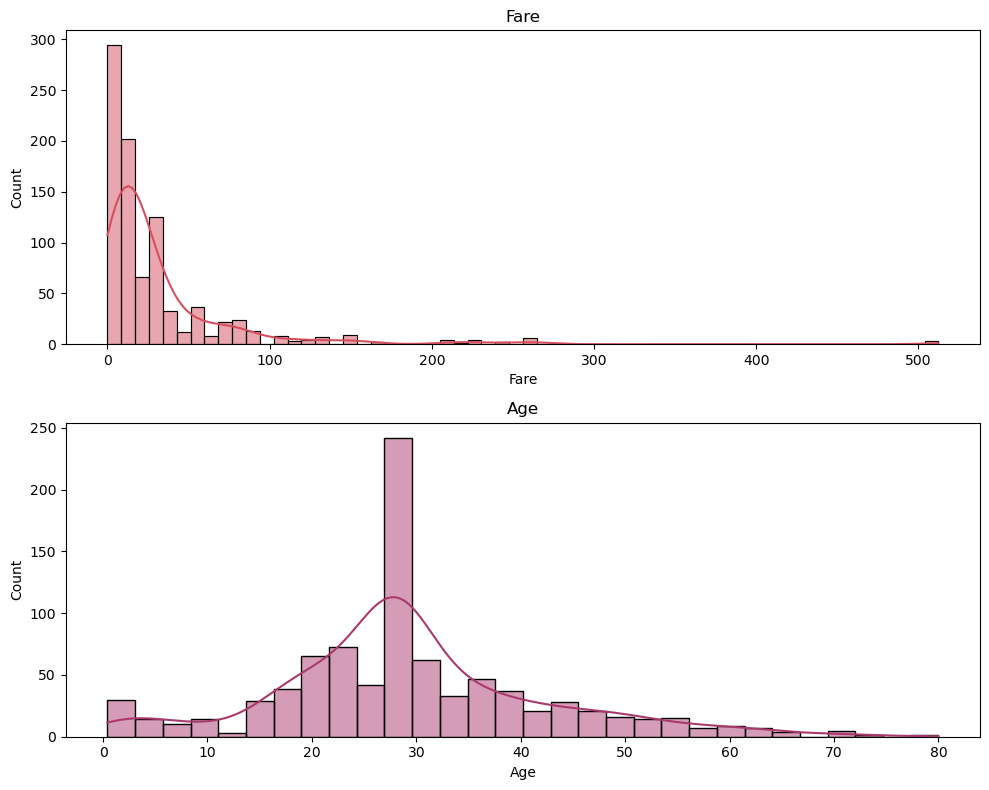

In [14]:
fig, axes = plt.subplots(2,1, figsize=(10,8))
sns.histplot(train["Fare"], kde= True, ax=axes[0], color="#d64f5f")
sns.histplot(train["Age"], kde= True, ax=axes[1], color="#aa3a6e")


axes[0].set_title("Fare")
axes[1].set_title("Age")


plt.tight_layout()
plt.show()

    The histograms verify the skew results for Age and Fare.
    Fare is extremely right-skewed with noticable outliers between 150 & 512, the Median is the most representative measure of center and the IQR is the best measure of spread for this case because it is has resistance to outliers.
    Age shows a normal distribution around the mean [28-29], all measures of center and spread can be used to represent Age distribution.

#### Bivariate Analysis

#### Outlier Detection

In [15]:
for col in numeric_cols:
    q1 = train[col].quantile(0.25)
    q3 = train[col].quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    up = q3 + 1.5 * iqr
    train[f"{col} outliers"] = (train[col].values < low) | (train[col].values > up)

train.filter(like=" outliers").sum()

Age outliers          65
SibSp outliers        46
Parch outliers       213
Fare outliers        114
fam_size outliers     91
dtype: int64

    Fare and Parch have the highest percentage of outliers among numerical columns.

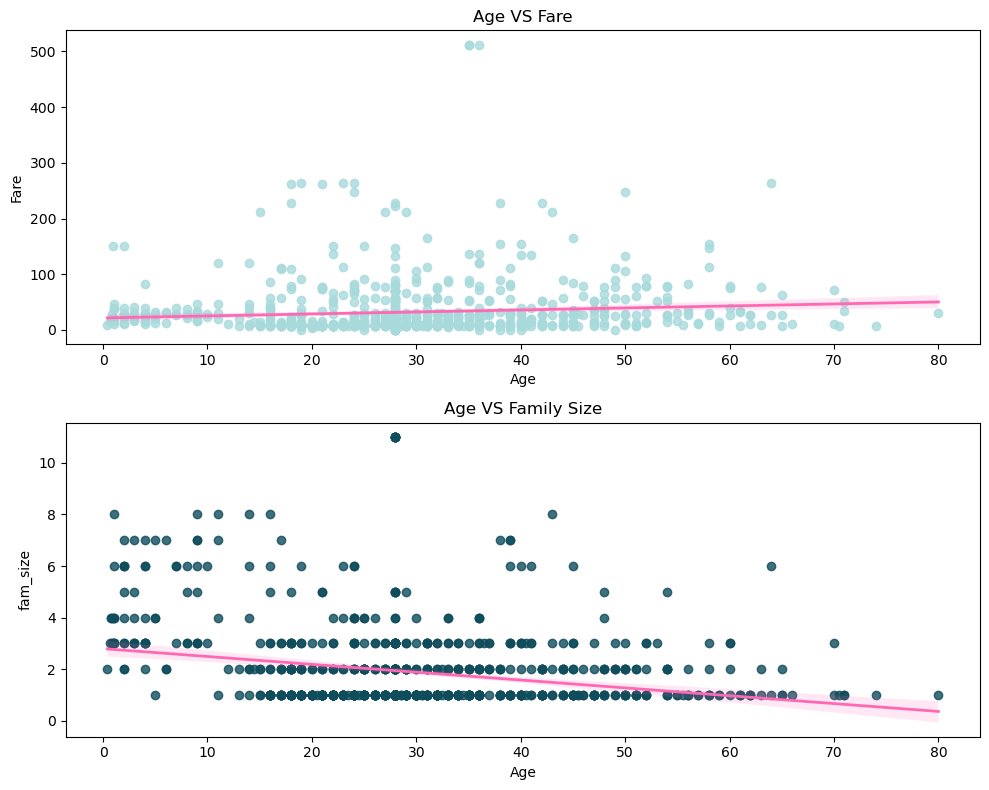

In [16]:
fig, axes = plt.subplots(2,1, figsize=(10,8))
sns.regplot(data=train, x="Age", y="Fare", ax=axes[0], color="#a8dadc", 
           line_kws={"color": "hotpink", "lw":2})
sns.regplot(data=train, x="Age", y="fam_size", ax=axes[1], color="#0f4c5c",
               line_kws={"color": "hotpink", "lw":2})
axes[0].set_title("Age VS Fare")
axes[1].set_title("Age VS Family Size")

plt.tight_layout()
plt.show()


    Age VS Fare:
        shows a slightligy positive relationship with consistent distribution of the data arounf the fitting line.
        Majority of the passengers paid below 200 and were between 20 and 50 years of age.
    Age VS Fmaily Size
        The plot show a negative realtionship meaning the older the age the smaller the family syze of the passenger.
        The data was rather scattered around the fitting line.
        This plot has relatively more outliers than the previos with majority of family sizes rangeing between 1 - 3 members.

#### Correlation Matrix & Heatmap

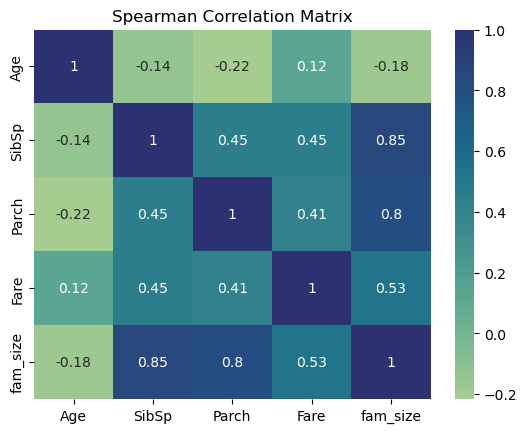

In [17]:
corr = train[numeric_cols].corr(method="spearman")
sns.heatmap(corr, cmap="crest", annot=True)
plt.title("Spearman Correlation Matrix")
plt.show()

    Strongest relationships:
        Sibsp & fam_size | 0.85
        Parch & Watch fam_size | 0.80

    The results are sensible becuase the more siblings, spouses, parents or children a passenger has the the larger their family size becomes. 

#### One-hot Encoding Categorical Columns

In [18]:
train = pd.get_dummies(train,columns=['Sex'], drop_first=True)
train = pd.get_dummies(train,columns=['Embarked'], drop_first=True)
train = pd.get_dummies(train,columns=['Pclass'], drop_first=True)

In [19]:
x = train.drop(["Survived"], axis = 1)
y = train["Survived"]

#### Scaling & train/test-split

In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


    Columns with binary data values or categorical values were converted by one-hot encoding to produce measurable scaled data.
    After that the dataset was split into features/target.
    Then, it was split into training/validation and testing data with a 80/20 ratio.
    Finally the data was scaled to provide a leveled basis for training.

## Step 3 - Model Training

### Baseline Model

In [21]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report

baseline = DummyClassifier(strategy = 'most_frequent')
baseline.fit(X_train_scaled, y_train)
y_pred_baseline = baseline.predict(X_test_scaled)

print("Baseline Accuracy:", accuracy_score(y_test, y_pred_baseline))
print(classification_report(y_test, y_pred_baseline, zero_division=0))

Baseline Accuracy: 0.6123595505617978
              precision    recall  f1-score   support

           0       0.61      1.00      0.76       109
           1       0.00      0.00      0.00        69

    accuracy                           0.61       178
   macro avg       0.31      0.50      0.38       178
weighted avg       0.37      0.61      0.47       178



The baseline model is unable to find survivors and shows an accuracy percentage of 61% and detects 100 of dead passengers.

### 1 - Logistic Regression

In [22]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)
predictions = lr.predict(X_test_scaled)
probabilities = lr.predict_proba(X_test_scaled) 

##### Confusion Matrix

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm=confusion_matrix(y_test, predictions)
print(cm)

[[91 18]
 [14 55]]


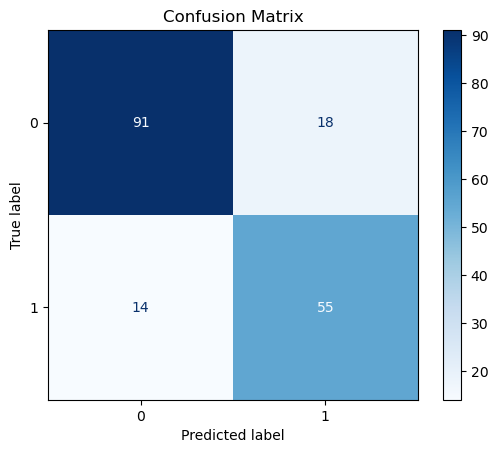

In [24]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=lr.classes_)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

146 reults were correct out of 178 - 82% accuracy.

##### Precision, Recall & F1

In [25]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.87      0.83      0.85       109
           1       0.75      0.80      0.77        69

    accuracy                           0.82       178
   macro avg       0.81      0.82      0.81       178
weighted avg       0.82      0.82      0.82       178



    0 [died] 
        Precision: The model is right 87% of the time when prediction passengers who died
        Recall: The model detected 83% of all dead passenger.
        F1: Better at predicting passengers who die.
    1 [survived] 
        Precision: The model is right 87% of the time when prediction passengers who Lived.
        Recall: The model detected 80% of all dead passenger.
        F1: Weaker at predicting passengers who live

##### AUC - ROC

In [26]:
from sklearn.metrics import roc_auc_score, roc_curve

probabilities_model = lr.predict_proba(X_test_scaled)[:,1]
auc = roc_auc_score(y_test, probabilities_model)
print(auc)

0.8414439569206222


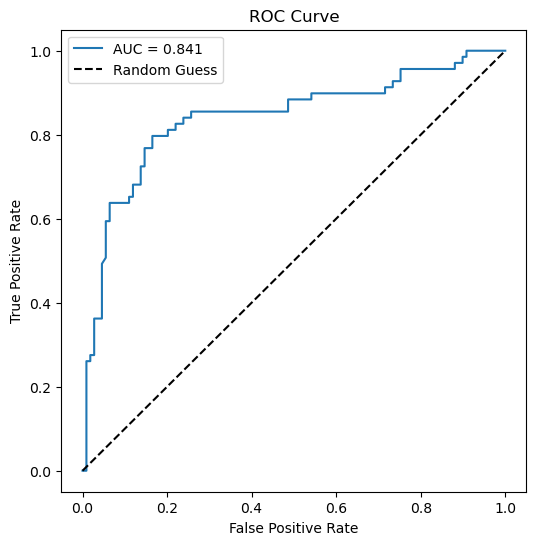

In [27]:
false_pos_rate, true_pos_rate, thresholds = roc_curve(y_test, probabilities_model)

plt.figure(figsize=(6,6))
plt.plot(false_pos_rate, true_pos_rate, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], "k--", label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

The model show an excellent performance in distinguishing between those who survived and those who did not survive. 84% represents the probability that the model ranks a random positive case( survived) above a random negative case (died). In other words, it is better in telling a survivor they will survive.

### 2 - Random Forest

In [28]:
from sklearn.ensemble import RandomForestClassifier


rfst = RandomForestClassifier(n_estimators=100, random_state=42)
rfst.fit(X_train, y_train)

y_train_pred= rfst.predict(X_train)
y_test_pred = rfst.predict(X_test)

print(f"Train score: {accuracy_score(y_train_pred, y_train)}")
print(f"Test score: {accuracy_score(y_test_pred, y_test)}")

Train score: 0.9845288326300985
Test score: 0.7528089887640449


The test score is affected by overfitting because of memorizing and splitting with no limit, as a result, the gap between the train and test score is wide.

In [29]:
rf = RandomForestClassifier(n_estimators=200,max_depth= 5, min_samples_leaf=5, random_state=42)
rf.fit(X_train, y_train)

y_train_pred= rf.predict(X_train)
y_test_pred = rf.predict(X_test)

print(f"Train score: {accuracy_score(y_train_pred, y_train)}")
print(f"Test score: {accuracy_score(y_test_pred, y_test)}")

Train score: 0.8509142053445851
Test score: 0.8089887640449438


In [30]:
importances = pd.Series(rfst.feature_importances_, index=X_train.columns).sort_values(ascending=False)
outlier_cols = [c for c in X_train.columns if 'outliers' in c.lower()]
X_train = X_train.drop(columns=outlier_cols)
X_test = X_test.drop(columns=outlier_cols)
importances

Fare                 0.261561
Sex_male             0.238451
Age                  0.230978
Pclass_3             0.056480
fam_size             0.046300
SibSp                0.028449
Embarked_S           0.027494
Parch                0.019249
Fare outliers        0.017253
Pclass_2             0.017069
Parch outliers       0.013999
Embarked_Q           0.013548
Age outliers         0.012714
fam_size outliers    0.008580
SibSp outliers       0.007875
dtype: float64

    The Random Forset model is notabely worse when predicting than training due to memorizing data rather than identifying patterns.
    The features of highest impact on a passenger's survival prediction were Fare , Sex_Male and Age.
    Being female, younger or having paid more were the strongest predictors  of survival.
    

## Step 4 - Evaluation

    After in-depth analysis of the two models and compairing them against the baseline
    
    Model        Accuracy  
    
    Baseline     0.61
    Logistic
    Regression   0.82
    Random
    Forest       0.81

     Both models substantially outperformed the baseline. The best model was the Logistic Regression model with 82% accuracy,84% AUC-ROC and a balanced F1-score of 77% on the survived class with no overfitting indicators.

     Random Forest initially showed overfitting with a 23% gap betweein train and test scores which was resolved by constraining the tree depth and removing non-predictive columns(max_depth= 5, min_samples_leaf=5). As a result, the test accuracy improved and the train VS test gap reduced to 4%. After all, Random forest was still outperformed slightly by Logistic Regression.

     Summary:
     Logistic Regression was selected as the best model becuase:
     - High accuracy and AUC-ROC
     - No overfitting